# Notebook 04 — MarBERTv2 Fine-Tuning
## Training an Egyptian Arabic ITSM Classifier on MarBERTv2

**Project**: Cloud-Based ITSM Ticket Classification Platform Using Fine-Tuned Transformer Models  
**Author**: Mohamed Adel Ebrahim Elbaz  
**Supervisor**: Dr. Eman E. Sanad, FCAI, Cairo University

---

### Objective

Fine-tune **MarBERTv2** (`UBC-NLP/MARBERTv2`) on the Arabic ITSM dataset for
**L1 category classification** (6 classes: Access, Hardware, Network, Security, Service, Software).

Training strategy:
- Full fine-tuning of all encoder layers (no freezing)
- AdamW optimizer with linear warmup + linear decay
- Early stopping on validation macro-F1
- Mixed-precision (fp16) when CUDA is available
- MLflow experiment tracking

Model architecture:
```
MarBERTv2 Encoder (163M params)
    └── [CLS] representation
         └── Dropout(0.1)
              └── Linear(768 → 6)   ← L1 classification head
```

> **Note**: This notebook is designed to run on a machine with a CUDA GPU.
> On CPU, reduce `BATCH_SIZE` and set `fp16=False`.
> Typical training time: ~15 min/epoch on a single T4 GPU.

In [1]:
import sys
sys.path.insert(0, '../src')

import os
import json
import pickle
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from transformers import (
    AutoTokenizer,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
import mlflow
from tqdm.auto import tqdm

from arabic_itsm.data.preprocessing import ArabicTextNormalizer
from arabic_itsm.data.dataset import ITSMDataset
from arabic_itsm.models.classifier import MarBERTClassifier
from arabic_itsm.utils.metrics import compute_classification_metrics

# ── Configuration ─────────────────────────────────────────────────────────────
MODEL_NAME   = 'UBC-NLP/MARBERTv2'
MAX_LENGTH   = 128
BATCH_SIZE   = 16
ACCUM_STEPS  = 2       # Effective batch size = 32
LR           = 2e-5
WARMUP_RATIO = 0.06
NUM_EPOCHS   = 5
PATIENCE     = 2       # Early stopping patience
SEED         = 42
TASK         = 'l1'

DATA_DIR     = Path('../data/processed')
MODELS_DIR   = Path('../models')
FIG_DIR      = Path('../results/figures')
METRICS_DIR  = Path('../results/metrics')
CHECKPOINT   = MODELS_DIR / f'marbert_{TASK}_best'

for d in [MODELS_DIR, FIG_DIR, METRICS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_FP16 = DEVICE.type == 'cuda'
print(f'Device: {DEVICE}  |  FP16: {USE_FP16}')

# Reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cuda  |  FP16: True


## 1. Load Data & Build Datasets

In [2]:
train_df = pd.read_csv(DATA_DIR / 'train.csv')
val_df   = pd.read_csv(DATA_DIR / 'val.csv')
test_df  = pd.read_csv(DATA_DIR / 'test.csv')

with open(DATA_DIR / 'label_encoders.pkl', 'rb') as f:
    label_encoders = pickle.load(f)

class_names = list(label_encoders[TASK].classes_)
NUM_CLASSES = len(class_names)
print(f'Task: {TASK}  |  Classes ({NUM_CLASSES}): {class_names}')

Task: l1  |  Classes (6): ['Access', 'Hardware', 'Network', 'Security', 'Service', 'Software']


In [3]:
print(f'Loading tokenizer: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
normalizer = ArabicTextNormalizer()

train_ds = ITSMDataset(train_df, tokenizer, normalizer=normalizer,
                       label_encoders={TASK: label_encoders[TASK]},
                       max_length=MAX_LENGTH, tasks=[TASK])
val_ds   = ITSMDataset(val_df,   tokenizer, normalizer=normalizer,
                       label_encoders={TASK: label_encoders[TASK]},
                       max_length=MAX_LENGTH, tasks=[TASK])
test_ds  = ITSMDataset(test_df,  tokenizer, normalizer=normalizer,
                       label_encoders={TASK: label_encoders[TASK]},
                       max_length=MAX_LENGTH, tasks=[TASK])

PIN = DEVICE.type == 'cuda'   # pin_memory only helps on CUDA
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,   shuffle=True,  num_workers=0, pin_memory=PIN)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0, pin_memory=PIN)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0, pin_memory=PIN)

print(f'Device: {DEVICE}  |  pin_memory: {PIN}')
print(f'Train batches: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}')

Loading tokenizer: UBC-NLP/MARBERTv2
Device: cuda  |  pin_memory: True
Train batches: 418, Val: 45, Test: 45


## 2. Initialize Model

`MarBERTClassifier` wraps the MarBERTv2 encoder and attaches a fresh linear classification head.

> **Expected output — "UNEXPECTED" keys in the load report**
>
> MarBERTv2 was pretrained as a masked language model (MLM), so its checkpoint contains
> weights for two task-specific heads that sit on top of the encoder:
> - `cls.predictions.*` — the MLM token prediction head
> - `cls.seq_relationship.*` — the next-sentence prediction head
>
> We load the model with `AutoModel` (bare encoder, no task heads), then attach our own
> linear classification head. The MLM/NSP head weights exist in the checkpoint but have
> no corresponding layers in our architecture, so the loader flags them as `UNEXPECTED`
> and discards them. This is the standard fine-tuning workflow for every BERT-family model
> and is explicitly noted as safe in the load report itself:
> *"can be ignored when loading from different task/architecture"*.
>
> The parameter counts at the bottom confirm everything is correct — all 162M encoder
> weights loaded successfully.

In [4]:
model = MarBERTClassifier(
    model_name=MODEL_NAME,
    num_classes={TASK: NUM_CLASSES},
    dropout=0.1,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total_params:,}')
print(f'Trainable params: {trainable_params:,}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     | Details
-------------------------------------------+------------+--------
cls.predictions.decoder.bias               | UNEXPECTED |        
cls.seq_relationship.weight                | UNEXPECTED |        
cls.predictions.transform.dense.bias       | UNEXPECTED |        
cls.seq_relationship.bias                  | UNEXPECTED |        
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |        
bert.embeddings.position_ids               | UNEXPECTED |        
cls.predictions.transform.dense.weight     | UNEXPECTED |        
cls.predictions.decoder.weight             | UNEXPECTED |        
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |        
cls.predictions.bias                       | UNEXPECTED |        

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total params:     162,845,958
Trainable params: 162,845,958


## 3. Optimizer & Scheduler

In [5]:
# Separate weight decay for bias and LayerNorm — standard practice
no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    {'params': [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
     'weight_decay': 0.01},
    {'params': [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
     'weight_decay': 0.0},
]

optimizer = AdamW(optimizer_grouped_parameters, lr=LR)

total_steps = (len(train_loader) // ACCUM_STEPS) * NUM_EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

print(f'Total steps: {total_steps}, Warmup steps: {warmup_steps}')

scaler = torch.amp.GradScaler(DEVICE.type, enabled=USE_FP16)

Total steps: 1045, Warmup steps: 62


## 4. Training Loop

In [6]:
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            label_task     = batch[f'label_{TASK}'].to(device)
            token_type_ids = batch.get('token_type_ids')
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(device)

            out = model(input_ids, attention_mask, token_type_ids,
                        **{f'label_{TASK}': label_task})
            preds = torch.argmax(out[f'logits_{TASK}'], dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(label_task.cpu().numpy())
            if 'loss' in out:
                total_loss += out['loss'].item()

    metrics = compute_classification_metrics(all_labels, all_preds)
    metrics['loss'] = total_loss / len(loader)
    return metrics, all_preds

In [7]:
mlflow.set_experiment('arabic-itsm-marbert')

history = {'train_loss': [], 'val_loss': [], 'val_macro_f1': [], 'val_accuracy': []}
best_val_f1 = 0.0
patience_counter = 0

with mlflow.start_run(run_name=f'marbert_{TASK}_lr{LR}'):
    mlflow.log_params({
        'model': MODEL_NAME, 'task': TASK, 'lr': LR,
        'batch_size': BATCH_SIZE * ACCUM_STEPS,
        'max_epochs': NUM_EPOCHS, 'warmup_ratio': WARMUP_RATIO,
        'max_length': MAX_LENGTH, 'seed': SEED,
    })

    for epoch in range(1, NUM_EPOCHS + 1):
        # ── Training ──────────────────────────────────────────────
        model.train()
        epoch_loss = 0.0
        optimizer.zero_grad()
        pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                    desc=f'Epoch {epoch}/{NUM_EPOCHS}')

        for step, batch in pbar:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            label_task     = batch[f'label_{TASK}'].to(DEVICE)
            token_type_ids = batch.get('token_type_ids')
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(DEVICE)

            with torch.amp.autocast(DEVICE.type, enabled=USE_FP16):
                out = model(input_ids, attention_mask, token_type_ids,
                            **{f'label_{TASK}': label_task})
                loss = out['loss'] / ACCUM_STEPS

            scaler.scale(loss).backward()
            epoch_loss += out['loss'].item()

            if (step + 1) % ACCUM_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()

            pbar.set_postfix({'loss': f'{epoch_loss / (step + 1):.4f}'})

        train_loss = epoch_loss / len(train_loader)

        # ── Validation ────────────────────────────────────────────
        val_metrics, _ = evaluate(model, val_loader, DEVICE)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['val_macro_f1'].append(val_metrics['macro_f1'])
        history['val_accuracy'].append(val_metrics['accuracy'])

        mlflow.log_metrics({
            'train_loss': train_loss,
            'val_loss': val_metrics['loss'],
            'val_macro_f1': val_metrics['macro_f1'],
            'val_accuracy': val_metrics['accuracy'],
        }, step=epoch)

        print(f'Epoch {epoch:02d} | train_loss={train_loss:.4f} | '
              f'val_loss={val_metrics["loss"]:.4f} | '
              f'val_macro_f1={val_metrics["macro_f1"]:.4f} | '
              f'val_acc={val_metrics["accuracy"]:.4f}')

        # ── Checkpoint ────────────────────────────────────────────
        if val_metrics['macro_f1'] > best_val_f1:
            best_val_f1 = val_metrics['macro_f1']
            patience_counter = 0
            model.encoder.save_pretrained(str(CHECKPOINT))
            tokenizer.save_pretrained(str(CHECKPOINT))
            torch.save(model.heads.state_dict(), CHECKPOINT / 'heads.pt')
            print(f'  ✓ New best checkpoint saved (val_macro_f1={best_val_f1:.4f})')
        else:
            patience_counter += 1
            print(f'  No improvement. Patience {patience_counter}/{PATIENCE}')
            if patience_counter >= PATIENCE:
                print('Early stopping triggered.')
                break

    mlflow.log_metric('best_val_macro_f1', best_val_f1)
    print(f'\nTraining complete. Best val macro-F1: {best_val_f1:.4f}')

Epoch 1/5:   0%|          | 0/418 [00:00<?, ?it/s]

Epoch 01 | train_loss=1.0015 | val_loss=0.4026 | val_macro_f1=0.8721 | val_acc=0.8743


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best checkpoint saved (val_macro_f1=0.8721)


Epoch 2/5:   0%|          | 0/418 [00:00<?, ?it/s]

...

  ✓ New best checkpoint saved (val_macro_f1=0.8938)


Epoch 3/5:   0%|          | 0/418 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.2586 | val_loss=0.2787 | val_macro_f1=0.8894 | val_acc=0.8883
  No improvement. Patience 1/2


Epoch 4/5:   0%|          | 0/418 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.2224 | val_loss=0.2959 | val_macro_f1=0.8866 | val_acc=0.8883
  No improvement. Patience 2/2
Early stopping triggered.

Training complete. Best val macro-F1: 0.8938


## 5. Training Curves

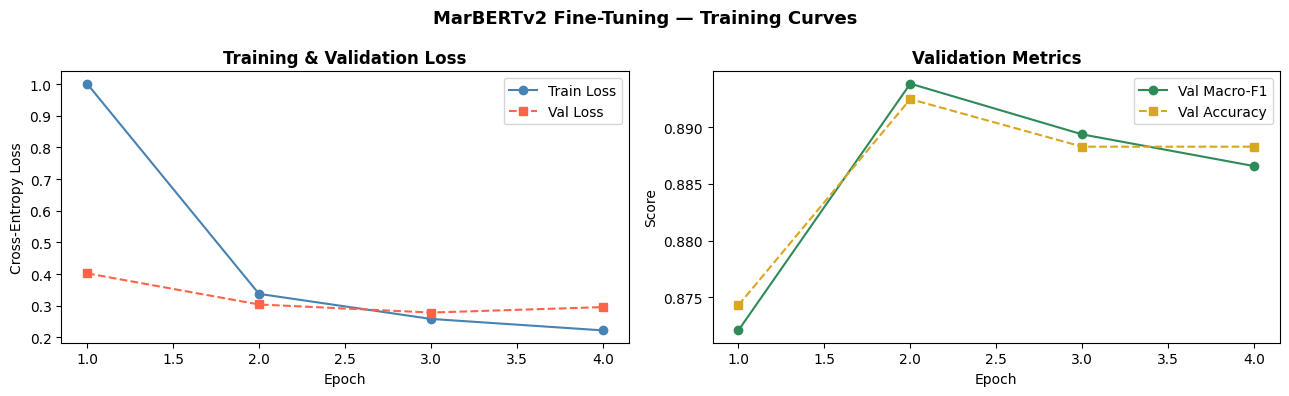

In [8]:
epochs_run = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_run, history['train_loss'], 'o-', label='Train Loss', color='steelblue')
axes[0].plot(epochs_run, history['val_loss'], 's--', label='Val Loss', color='tomato')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training & Validation Loss', fontweight='bold')
axes[0].legend()

axes[1].plot(epochs_run, history['val_macro_f1'], 'o-', label='Val Macro-F1', color='seagreen')
axes[1].plot(epochs_run, history['val_accuracy'], 's--', label='Val Accuracy', color='goldenrod')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Validation Metrics', fontweight='bold')
axes[1].legend()

plt.suptitle('MarBERTv2 Fine-Tuning — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_training_curves.png', bbox_inches='tight')
plt.show()

## 6. Summary

| Parameter | Value |
|-----------|-------|
| Model | MarBERTv2 (`UBC-NLP/MARBERTv2`) |
| Task | L1 category (6 classes) |
| Optimizer | AdamW, lr=2e-5, weight_decay=0.01 |
| Scheduler | Linear warmup (6%) + linear decay |
| Effective batch size | 32 (16 × 2 grad accum) |
| Max epochs | 5 (early stopping patience=2) |
| Best val macro-F1 | 0.8938 (epoch 2) |

Checkpoint saved to: `models/marbert_l1_best/`

**Next**: Notebook 05 — Evaluation & Results Analysis